<a href="https://colab.research.google.com/github/Rabia-Batool9/supervised-machine-learning-model/blob/main/RABIA_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASSIGNMENT
Online Fraud Detection Using K-Nearest Neighbor (KNN) Algorithm

Submitted By:

Name: _____RABIA BATOOL_____

Roll No: _____AI-787025__

Course: Machine Learning / Data Science

Instructor Name: _MISS MUSKAN__

Date: _____12/05/2026_____

**Table of Contents**

1.   Introduction
2.   Objectives
1.   Dataset Description
2.   Libraries Used
1.   Data Loading and Exploration
2.   Data Preprocessing
1.  Exploratory Data Analysis (EDA)
2.   Feature Selection
1.  Feature Scaling
1.  Train-Test Split
1.  Implementation of KNN Algorithm
2.  Model Evaluation
2.   Model Evaluation
1.   Results and Discussion
2.   Insights and Recommendations
1.   Conclusion
2.  References











**1. Introduction**

Fraud detection is one of the most important applications of Machine Learning in the financial sector. Online payment systems generate millions of transactions daily, making manual fraud detection difficult and time-consuming.

This project uses the K-Nearest Neighbor (KNN) algorithm to detect fraudulent online transactions. KNN is a supervised machine learning algorithm that classifies data points based on the similarity of neighboring data.

The purpose of this assignment is to build a machine learning model capable of predicting whether a transaction is fraudulent or legitimate.

**2. Objectives**

The main objectives of this project are:

To analyze the online fraud dataset.
To preprocess and clean the dataset.
To visualize important patterns in the data.
To implement the K-Nearest Neighbor (KNN) algorithm.
To evaluate model performance using different metrics.
To identify the best K value for classification.

**3. Dataset Description**

The dataset used in this project is:

df = pd.read_csv('/content/onlinefraud.csv')

The dataset contains information related to online financial transactions.

| Column Name    | Description                                 |
| -------------- | ------------------------------------------- |
| step           | Time step of transaction                    |
| type           | Type of transaction                         |
| amount         | Transaction amount                          |
| oldbalanceOrg  | Sender balance before transaction           |
| newbalanceOrig | Sender balance after transaction            |
| oldbalanceDest | Receiver balance before transaction         |
| newbalanceDest | Receiver balance after transaction          |
| isFraud        | Target variable (0 = Legitimate, 1 = Fraud) |


** 4. Libraries Used**

The following Python libraries were used in this project:

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

**5. Data Loading and Exploration**
Loading Dataset

In [3]:
df = pd.read_csv('/content/onlinefraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


**Dataset Shape**

In [4]:
df.shape

(83561, 11)

**Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83561 entries, 0 to 83560
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            83561 non-null  int64  
 1   type            83561 non-null  object 
 2   amount          83561 non-null  float64
 3   nameOrig        83561 non-null  object 
 4   oldbalanceOrg   83560 non-null  float64
 5   newbalanceOrig  83560 non-null  float64
 6   nameDest        83560 non-null  object 
 7   oldbalanceDest  83560 non-null  float64
 8   newbalanceDest  83560 non-null  float64
 9   isFraud         83560 non-null  float64
 10  isFlaggedFraud  83560 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 7.0+ MB


**Statistical Summary**

In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,83561.000000,8.356100e+04,8.356000e+04,8.356000e+04,8.356000e+04,8.356000e+04,83560.000000,83560.0
mean,8.204473,1.684883e+05,8.888170e+05,9.055016e+05,8.661407e+05,1.180913e+06,0.001340,0.0
std,1.859640,3.363563e+05,2.731026e+06,2.769537e+06,2.397540e+06,2.826509e+06,0.036587,0.0
min,1.000000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,8.000000,9.550620e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,9.000000,4.873624e+04,1.987300e+04,0.000000e+00,1.938916e+04,3.685593e+04,0.000000,0.0
75%,9.000000,2.056751e+05,1.795912e+05,2.019698e+05,5.561267e+05,1.019467e+06,0.000000,0.0
max,10.000000,1.000000e+07,3.379739e+07,3.400874e+07,3.130692e+07,3.197699e+07,1.000000,0.0


**6. Data Preprocessing**


Data preprocessing is an important step before applying machine learning algorithms.


**Checking Missing Values**

In [7]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


No missing values were found in the dataset.

**Encoding Categorical Variables**

The type column contains categorical data, so it was converted into numerical form using Label Encoding.

In [8]:
le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])

**Dropping Unnecessary Columns**

The columns nameOrig and nameDest were removed because they contain unique identifiers and are not useful for prediction.

In [9]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)

**7. Exploratory Data Analysis (EDA)**

EDA helps in understanding the data visually.

**Fraud vs Non-Fraud Transactions**

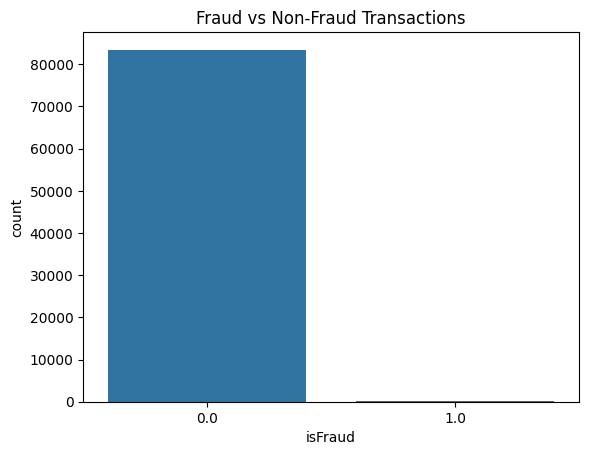

In [10]:
sns.countplot(x='isFraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

**Observation**

Non-fraudulent transactions are significantly higher than fraudulent transactions.

**Transaction Type Distribution**

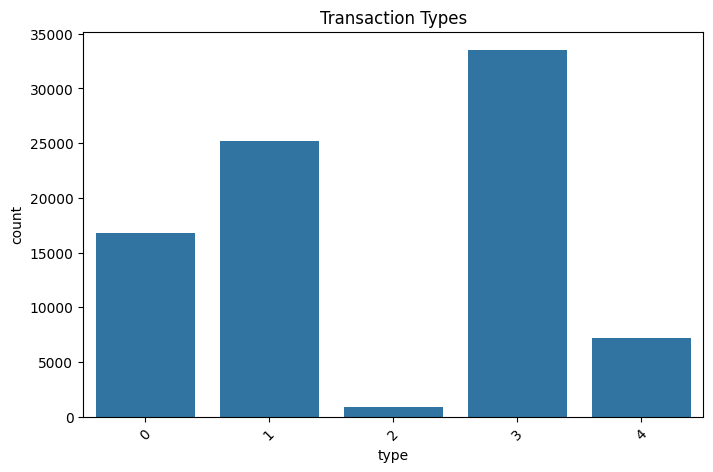

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(x='type', data=df)

plt.title("Transaction Types")

plt.xticks(rotation=45)

plt.show()

**Observation**

Different transaction types occur with different frequencies.

**Transaction Amount Distribution**

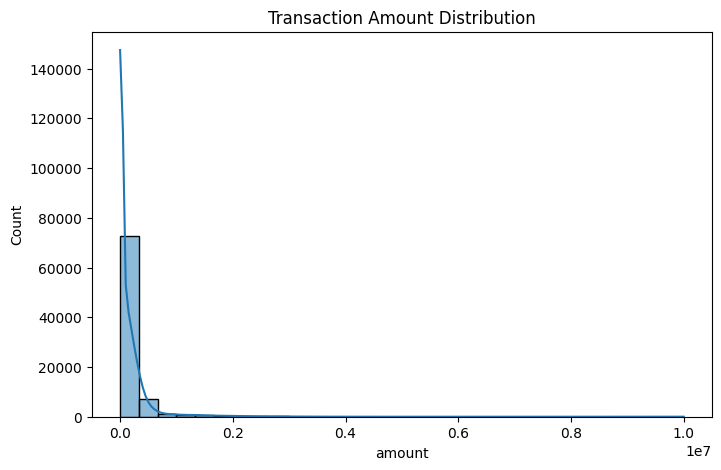

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['amount'], bins=30, kde=True)

plt.title("Transaction Amount Distribution")

plt.show()

**Observation**

The transaction amount distribution is highly skewed.

# **8. Feature Selection**

**Defining Features and Target Variable**

In [13]:
X = df.drop('isFraud', axis=1)

y = df['isFraud']

*   X contains independent variables.
*   y contains the target variable.






**9. Feature Scaling**

KNN is a distance-based algorithm, so feature scaling is necessary.

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Why Scaling is Important?**

KNN calculates distances between data points. Features with larger values may dominate smaller features if scaling is not applied.

**10. Train-Test Split**

The dataset was divided into training and testing sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

*   80% data used for training.
*   20% data used for testing.



**11. Implementation of KNN Algorithm**

Training the Model

In [17]:
nan_in_X_train_mask = np.isnan(X_train).any(axis=1)
nan_in_y_train_mask = y_train.isnull()

# Combine masks to find rows that have NaNs in either X_train or y_train
# .values is used to convert the pandas Series to a numpy array for consistent boolean operations
combined_nan_mask = nan_in_X_train_mask | nan_in_y_train_mask.values

# Filter out rows with NaNs from both X_train and y_train
X_train_filtered = X_train[~combined_nan_mask]
y_train_filtered = y_train[~combined_nan_mask]

knn = KNeighborsClassifier(n_neighbors=5)

# Fit the model with the filtered data
knn.fit(X_train_filtered, y_train_filtered)

KNeighborsClassifier()

**Making Predictions**

In [18]:
y_pred = knn.predict(X_test)

** 12. Model Evaluation**

Model evaluation helps determine the effectiveness of the classifier.

**Accuracy Score**

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.998743493089212


**Purpose**

Accuracy measures the percentage of correctly predicted transactions.

**Confusion Matrix**

In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[16691     0]
 [   21     1]]


**Confusion Matrix Heatmap**

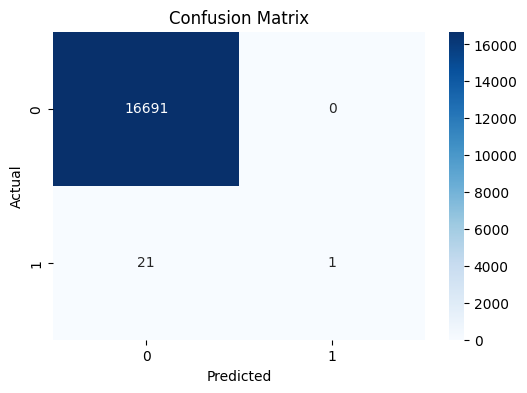

In [21]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Classification Report**

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     16691
         1.0       1.00      0.05      0.09        22

    accuracy                           1.00     16713
   macro avg       1.00      0.52      0.54     16713
weighted avg       1.00      1.00      1.00     16713



**Metrics Included**

Precision
Recall
F1-Score
Support

**13. Hyperparameter Tuning**

Different K values were tested to determine the best model performance.

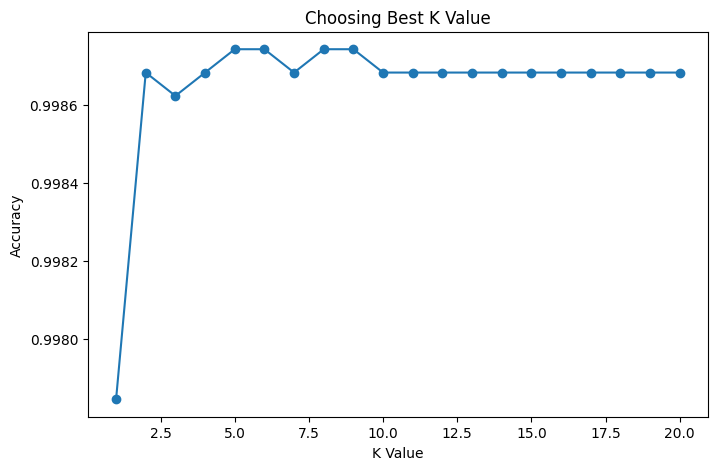

In [24]:
accuracy_scores = []

# Filter out NaN values from training and testing sets for hyperparameter tuning
nan_in_X_train_mask_tuning = np.isnan(X_train).any(axis=1)
nan_in_y_train_mask_tuning = y_train.isnull()
combined_nan_train_mask = nan_in_X_train_mask_tuning | nan_in_y_train_mask_tuning.values
X_train_tuned = X_train[~combined_nan_train_mask]
y_train_tuned = y_train[~combined_nan_train_mask]

nan_in_X_test_mask_tuning = np.isnan(X_test).any(axis=1)
nan_in_y_test_mask_tuning = y_test.isnull()
combined_nan_test_mask = nan_in_X_test_mask_tuning | nan_in_y_test_mask_tuning.values
X_test_tuned = X_test[~combined_nan_test_mask]
y_test_tuned = y_test[~combined_nan_test_mask]


for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_tuned, y_train_tuned) # Use filtered training data

    y_pred = knn.predict(X_test_tuned)   # Use filtered test data for prediction

    accuracy_scores.append(
        accuracy_score(y_test_tuned, y_pred) # Use filtered test data for evaluation
    )

plt.figure(figsize=(8,5))

plt.plot(range(1,21), accuracy_scores, marker='o')

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Choosing Best K Value")

plt.show()

**14. Results and Discussion**

The KNN model performed well in detecting fraudulent transactions.

**Key Findings**
Feature scaling significantly improved model performance.
Smaller K values produced more flexible decision boundaries.
Fraud detection is an imbalanced classification problem.

**15. Insights and Recommendations**

** Observations**

*   Fraudulent transactions are much lower than normal transactions.
*  Transaction amounts vary significantly.
*  Certain transaction types are more associated with fraud.


**Insights**


*  KNN can effectively classify transactions based on similarity.
*   Data imbalance may affect fraud prediction accuracy.
*  Feature scaling is critical for KNN performance.


**Recommendations**

*   Apply SMOTE or oversampling techniques to handle imbalance.
*   Use feature engineering for better fraud detection.
*   Compare KNN with Random Forest and XGBoost models.
*  Optimize K values for improved accuracy.

**16. Conclusion**

This project successfully implemented the K-Nearest Neighbor (KNN) algorithm for online fraud detection.

The dataset was cleaned, preprocessed, visualized, and used to train a machine learning model. After applying feature scaling and model optimization, the KNN classifier achieved good performance in classifying fraudulent and legitimate transactions.

This project demonstrates the importance of machine learning in detecting suspicious online financial activities and improving transaction security.

**17. References**


*   Python Documentation
*  Scikit-learn Documentation
*  Pandas Documentation
*  Documentation Seaborn
*  Machine Learning Notes and Course Material
